In [1]:
!pip install -U ipywidgets 
!pip install ultralytics 
!pip install torch torchvision opencv-python matplotlib 
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.0/214.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.9
    Uninstalling widgetsnbextension-3.6.9:
      Successfully uninstalled widgetsnbextension-3.6.9
  Attempting uninstall: jupyterlab_widgets
    Found existing installation: jupyterlab_widgets 3.0.11
    Uninstalling jupyterlab_widgets-3.0.11:
      Successfully uninstalled jupyterlab_widgets-3.0.11
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 

In [2]:
# to copy dataset from input directory to working directory 

import shutil 
import os 

# Source directory (read-only)
source_dir = "/kaggle/input/dataset" 

# Destination directory (writable)
destination_dir = "/kaggle/working/dataset" 

# Copy the dataset recursively, including all subfolders and files 
shutil.copytree(source_dir, destination_dir) 

print(f"Dataset copied to {destination_dir}") 

Dataset copied to /kaggle/working/dataset


In [3]:
import numpy as np 
import torch 
print("CUDA available:", torch.cuda.is_available()) 
print("Device count:", torch.cuda.device_count()) 
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

CUDA available: True
Device count: 2
CUDA device name: Tesla T4


In [7]:
from ultralytics import YOLO 
import matplotlib.pyplot as plt
import os # Import the os module

model_path = "yolov8n.pt"  # Pretrained YOLOv8 model (n = nano, s = small, etc.)
# Load YOLO model
model = YOLO(model_path) 

In [9]:
from ultralytics import YOLO 
import matplotlib.pyplot as plt
import os # Import the os module

# Defining paths
data_yaml = "/kaggle/working/dataset/data.yaml"  # Path to data.yaml
model_path = "yolov8n.pt"  # Pretrained YOLOv8 model (n = nano, s = small, etc.)

# Load YOLO model
model = YOLO(model_path)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Train YOLOv8
results = model.train(
    data=data_yaml,  # Path to data.yaml
    epochs=50,       # Number of epochs
    imgsz=640,       # Image size
    batch=16,        # Batch size
    workers=4,       # Number of workers for data loading
    device='device', # Uses GPU for training
    
)


Ultralytics 8.3.120 🚀 Python-3.10.14 torch-2.4.0 CUDA:device (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=device, workers=4, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, lin

100%|██████████| 755k/755k [00:00<00:00, 44.2MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 174MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1765.5±678.0 MB/s, size: 65.1 KB)


...

      50/50      2.52G     0.8959     0.6414      1.355          8        640: 100%|██████████| 66/66 [00:10<00:00,  6.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:01<00:00,  5.92it/s]

                   all        262        401      0.838      0.808      0.857      0.583



50 epochs completed in 0.176 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.120 🚀 Python-3.10.14 torch-2.4.0 CUDA:device (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  3.77it/s]


                   all        262        401      0.846      0.817      0.861      0.586
                  crop        126        228      0.847      0.802      0.875      0.623
                  weed        137        173      0.844      0.832      0.846      0.548
Speed: 0.3ms preprocess, 2.0ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to runs/detect/train


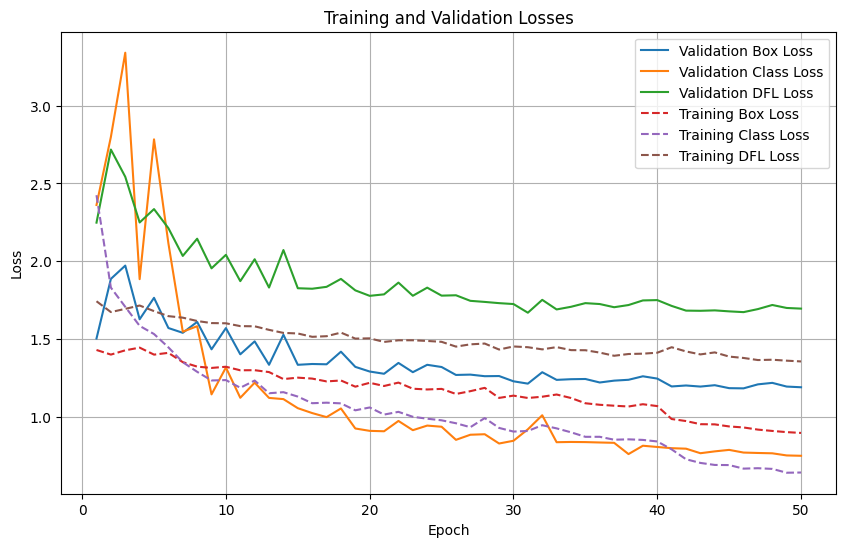

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

results_file = "runs/detect/train/results.csv"
metrics = pd.read_csv(results_file)

plt.figure(figsize=(10, 6))

plt.plot(metrics['epoch'], metrics['val/box_loss'], label='Validation Box Loss')
plt.plot(metrics['epoch'], metrics['val/cls_loss'], label='Validation Class Loss')
plt.plot(metrics['epoch'], metrics['val/dfl_loss'], label='Validation DFL Loss')

plt.plot(metrics['epoch'], metrics['train/box_loss'], linestyle='--', label='Training Box Loss')
plt.plot(metrics['epoch'], metrics['train/cls_loss'], linestyle='--', label='Training Class Loss')
plt.plot(metrics['epoch'], metrics['train/dfl_loss'], linestyle='--', label='Training DFL Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# Evaluating the trained model on the validation set
metrics = model.val()
print(metrics)  # It will display metrics such as mAP, precision, recall

# Inference on test images
results = model.predict(source='/kaggle/working/dataset/images/test', save=True)

Ultralytics 8.3.120 🚀 Python-3.10.14 torch-2.4.0 CUDA:device (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1252.0±317.9 MB/s, size: 56.6 KB)


val: Scanning /kaggle/working/dataset/labels/val.cache... 262 images, 0 backgrounds, 0 corrupt: 100%|██████████| 262/262 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.60it/s]


                   all        262        401      0.846      0.816       0.86      0.585
                  crop        126        228      0.847        0.8      0.874      0.623
                  weed        137        173      0.845      0.832      0.846      0.548
Speed: 1.6ms preprocess, 4.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7df69aff4d60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,    

In [12]:
detections = []
for i, result in enumerate(results):
    for *xyxy, conf, cls in result.boxes.data.tolist():
        detections.append({
            'image_path': results[i].path,
            'label': int(cls),
            'bbox': [int(x) for x in xyxy]
        })

np.save('yolo_detections.npy', detections)

In [11]:
import os
save_dir = "/kaggle/working/dataset/trained_modelsave"
os.makedirs(save_dir, exist_ok=True)
model_path = save_dir + "/best.pt"

if os.path.exists(model_path):
    os.remove(model_path)

model.save(model_path) 

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import numpy as np
import cv2

class WeedDetectionCNN(nn.Module):
    def __init__(self):
        super(WeedDetectionCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 160, 160)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (16, 80, 80)
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Output: (32, 80, 80)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (32, 40, 40)
        )
        self.flatten_size = 32 * 40 * 40

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 128),  # Adjusted size
            nn.ReLU(),
            nn.Linear(128, 1),  # Binary classification
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Custom Dataset for CNN fine-tuning
class WeedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


# Load the YOLO detections and prepare data for CNN fine-tuning
def load_yolo_detections(detections_path):
    detections = np.load(detections_path, allow_pickle=True)
    images = []
    labels = []
    for detection in detections:
        image_path = detection['image_path']
        label = detection['label']  # Weed (1) or not (0)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
        labels.append(label)
    return images, labels


# Paths
detections_path = "yolo_detections.npy"  # Replace with actual path
images, labels = load_yolo_detections(detections_path)

# Data transformation
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160, 160)),  # Resize images for CNN
    transforms.ToTensor(),
])

# Prepare dataset and dataloader
dataset = WeedDataset(images, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Initialize CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = WeedDetectionCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Train CNN
epochs = 10
losses = []  # Create an empty list to store losses
for epoch in range(epochs):
    cnn_model.train()
    total_loss = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer.zero_grad()
        outputs = cnn_model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    epoch_loss = total_loss / len(dataloader)  # Calculate average loss for the epoch
    losses.append(epoch_loss)  # Append the loss to the list
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

# Save the fine-tuned CNN model
cnn_save_path = "/kaggle/working/dataset/trained_modelsave/cnn_weed_detection.pt"
torch.save(cnn_model.state_dict(), cnn_save_path)
print(f"Model saved at {cnn_save_path}") 

Epoch 1/10, Loss: 0.8378
Epoch 2/10, Loss: 0.6361
Epoch 3/10, Loss: 0.5573
Epoch 4/10, Loss: 0.4291
Epoch 5/10, Loss: 0.2701
Epoch 6/10, Loss: 0.3920
Epoch 7/10, Loss: 0.2302
Epoch 8/10, Loss: 0.1800
Epoch 9/10, Loss: 0.1117
Epoch 10/10, Loss: 0.1153
Model saved at /kaggle/working/dataset/trained_modelsave/cnn_weed_detection.pt


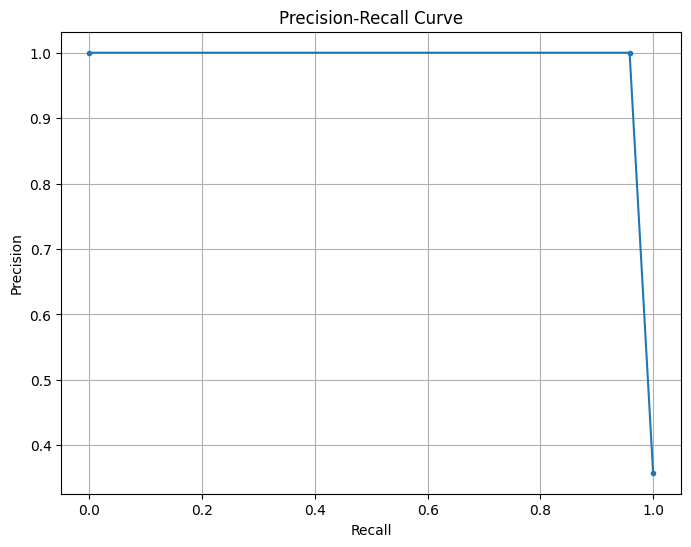

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

cnn_model.eval()

true_labels = []
predictions = []

with torch.no_grad():
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device).float()
        outputs = cnn_model(images).squeeze()

        # Convert model outputs to binary predictions (0 or 1)
        predicted_labels = (outputs >= 0.5).float()

        true_labels.extend(labels.cpu().numpy())
        predictions.extend(predicted_labels.cpu().numpy())

# Now you have 'true_labels' and 'predictions' populated
precision, recall, thresholds = precision_recall_curve(true_labels, predictions)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()


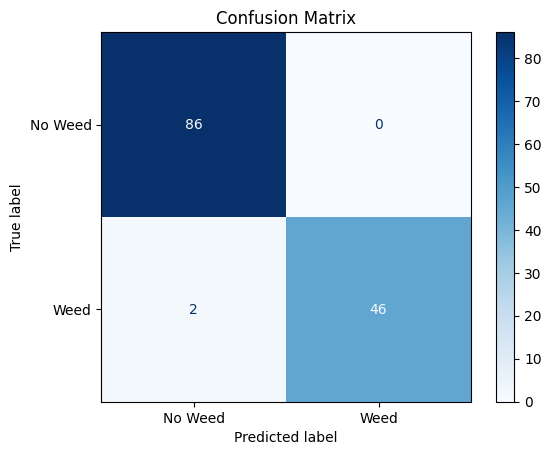

Accuracy: 0.9851
F1 Score: 0.9787


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# Convert predictions to a NumPy array and flatten it
predictions = np.array(predictions).flatten()

cm = confusion_matrix(true_labels, (predictions > 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Weed", "Weed"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(true_labels, (predictions > 0.5).astype(int))
f1 = f1_score(true_labels, (predictions > 0.5).astype(int))

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")


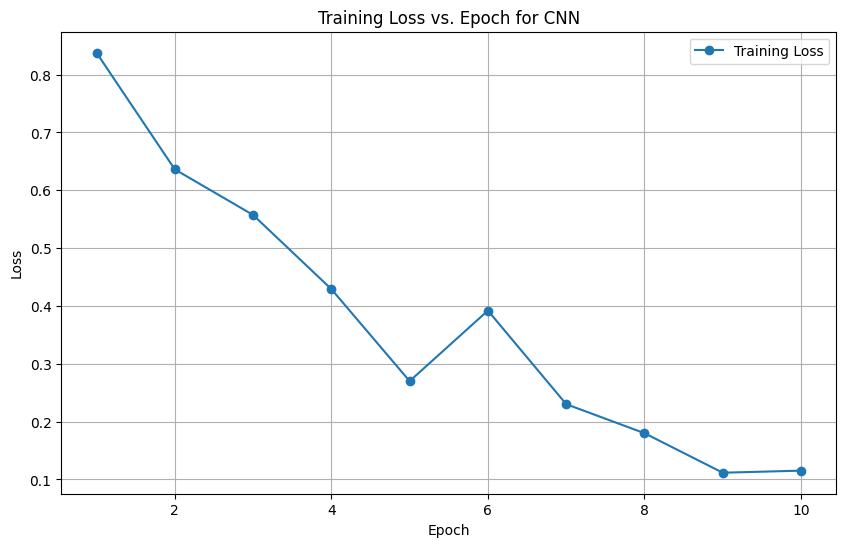

In [16]:
# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses, marker='o', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch for CNN")
plt.grid(True)
plt.legend()
plt.show()


image 1/1 /kaggle/working/dataset/images/test/Copy of agri_0_1677.jpeg: 640x640 2 weeds, 9.2ms
Speed: 4.4ms preprocess, 9.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


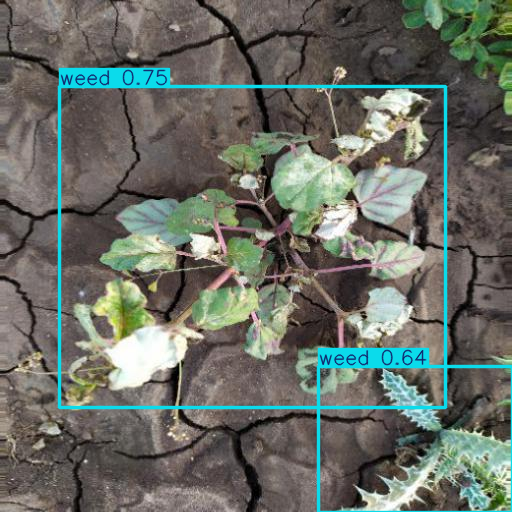

Bounding Boxes (xywh): tensor([[252.4391, 247.0057, 385.7969, 321.7408],
        [415.3681, 439.2345, 193.2638, 145.5311]], device='cuda:0')
Confidence: tensor([0.7549, 0.6389], device='cuda:0')
Class IDs: tensor([1., 1.], device='cuda:0')


In [17]:
results = model('/kaggle/working/dataset/images/test/Copy of agri_0_1677.jpeg')  # Predict on test images

# Visualize the predictions for each result (since results is a list)
for result in results:
    result.show()  # Show the image with detections for each result

# Access the bounding box details
for result in results:
    boxes = result.boxes
    print(f"Bounding Boxes (xywh): {boxes.xywh}")  # Print the bounding boxes in xywh format
    print(f"Confidence: {boxes.conf}")  # Print confidence scores for each detection
    print(f"Class IDs: {boxes.cls}")  # Print class IDs for the detected objects

# Save the annotated image
for result in results:
    result.save("annotated_image.jpg")  # Save the image with predictions

for result in results:
    result.save_txt("detection_results.txt")  # Save the detection results in a text file


In [ ]:
#ending the yolo and starting the cnn

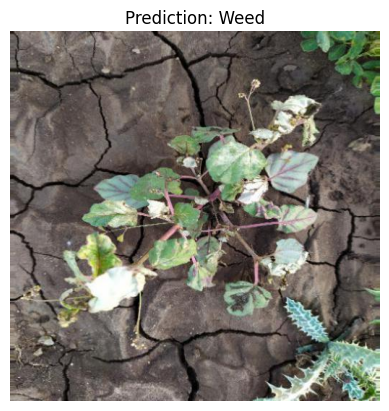

In [18]:
import torch
import cv2
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the CNN model (same structure as when you trained it)
class WeedDetectionCNN(torch.nn.Module):
    def __init__(self):
        super(WeedDetectionCNN, self).__init__()
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 160, 160)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (16, 80, 80)
            torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Output: (32, 80, 80)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (32, 40, 40)
        )

        # Calculate the flattened size after convolutions
        self.flatten_size = 32 * 40 * 40

        self.fc_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(self.flatten_size, 128),  # Adjusted size
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1),  # Binary classification
            torch.nn.Sigmoid(),
        ) 
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Define a function to test a single image
def test_single_image(image_path, model, device):
    # Load the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
    image = Image.fromarray(image)  # Convert to PIL image

    # Define the transformation to resize and convert the image to tensor
    transform = transforms.Compose([
        transforms.Resize((160, 160)),  # Resize image to match input size of CNN
        transforms.ToTensor(),          # Convert image to tensor
    ])

    # Apply transformations
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Set model to evaluation mode and make prediction
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        output = model(image_tensor).squeeze()  # Get the output
        prediction = torch.round(output)  # Round to 0 or 1 for binary classification

    # Show the image and prediction
    plt.imshow(image)
    plt.axis('off')  # Turn off axis
    plt.title(f"Prediction: {'Weed' if prediction.item() == 1 else 'Crop'}")  # Display prediction
    plt.show()

# Path to the image you want to test
image_path = '/kaggle/working/dataset/images/test/Copy of agri_0_1677.jpeg'  # Replace with the actual image path

# Load the fine-tuned model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = WeedDetectionCNN().to(device)

# Load the model's weights from the .pt file
cnn_model.load_state_dict(torch.load('/kaggle/working/dataset/trained_modelsave/cnn_weed_detection.pt'))  # Replace with actual path

# Test the model on the image
test_single_image(image_path, cnn_model, device)


image 1/1 /kaggle/working/dataset/images/test/Copy of agri_0_2221.jpeg: 640x640 1 crop, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


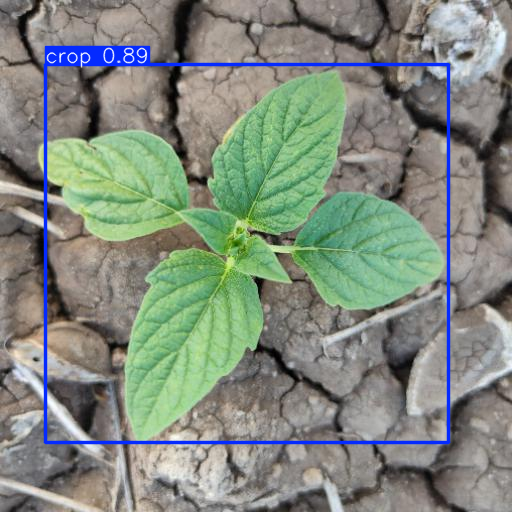

Bounding Boxes (xywh): tensor([[247.0053, 253.5581, 402.5432, 378.4221]], device='cuda:0')
Confidence: tensor([0.8855], device='cuda:0')
Class IDs: tensor([0.], device='cuda:0')


In [19]:
# Run predictions on the image
results = model('/kaggle/working/dataset/images/test/Copy of agri_0_2221.jpeg')  # Predict on test images

# Visualize the predictions for each result (since results is a list)
for result in results:
    result.show()  # Show the image with detections for each result

# Access the bounding box details
for result in results:
    boxes = result.boxes
    print(f"Bounding Boxes (xywh): {boxes.xywh}")  # Print the bounding boxes in xywh format
    print(f"Confidence: {boxes.conf}")  # Print confidence scores for each detection
    print(f"Class IDs: {boxes.cls}")  # Print class IDs for the detected objects

# Save the annotated image
for result in results:
    result.save("annotated_image.jpg")  # Save the image with predictions

# Save detection results as a text file
for result in results:
    result.save_txt("detection_results.txt")  # Save the detection results in a text file


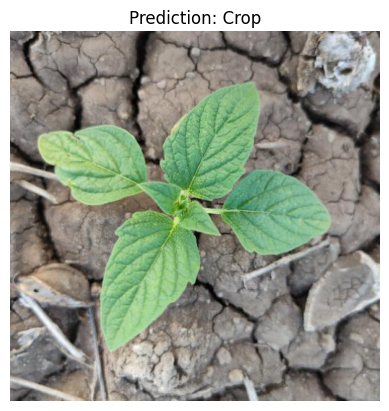

In [20]:
import torch
import cv2
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the CNN model (same structure as when you trained it)
class WeedDetectionCNN(torch.nn.Module):
    def __init__(self):
        super(WeedDetectionCNN, self).__init__()
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 160, 160)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (16, 80, 80)
            torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Output: (32, 80, 80)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (32, 40, 40)
        )

        # Calculate the flattened size after convolutions
        self.flatten_size = 32 * 40 * 40

        self.fc_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(self.flatten_size, 128),  # Adjusted size
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1),  # Binary classification
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Define a function to test a single image
def test_single_image(image_path, model, device):
    # Load the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
    image = Image.fromarray(image)  # Convert to PIL image

    # Define the transformation to resize and convert the image to tensor
    transform = transforms.Compose([
        transforms.Resize((160, 160)),  # Resize image to match input size of CNN
        transforms.ToTensor(),          # Convert image to tensor
    ])

    # Apply transformations
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Set model to evaluation mode and make prediction
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        output = model(image_tensor).squeeze()  # Get the output
        prediction = torch.round(output)  # Round to 0 or 1 for binary classification

    # Show the image and prediction
    plt.imshow(image)
    plt.axis('off')  # Turn off axis
    plt.title(f"Prediction: {'Weed' if prediction.item() == 1 else 'Crop'}")  # Display prediction
    plt.show()

# Path to the image you want to test
image_path = '/kaggle/working/dataset/images/test/Copy of agri_0_2221.jpeg'  # Replace with the actual image path

# Load the fine-tuned model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = WeedDetectionCNN().to(device) 

# Load the model's weights from the .pt file
cnn_model.load_state_dict(torch.load('/kaggle/working/dataset/trained_modelsave/cnn_weed_detection.pt'))  # Replace with actual path

# Test the model on the image
test_single_image(image_path, cnn_model, device)



0: 640x640 1 crop, 7.4ms
Speed: 2.4ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


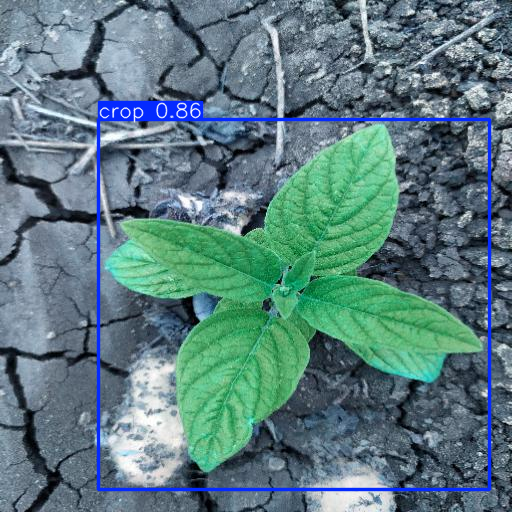

Bounding Boxes (xywh): tensor([[294.0344, 304.6934, 390.6179, 369.5403]], device='cuda:0')
Confidence Scores: tensor([0.8576], device='cuda:0')
Class IDs: tensor([0.], device='cuda:0')
CNN Prediction for crop: 0.017408879473805428


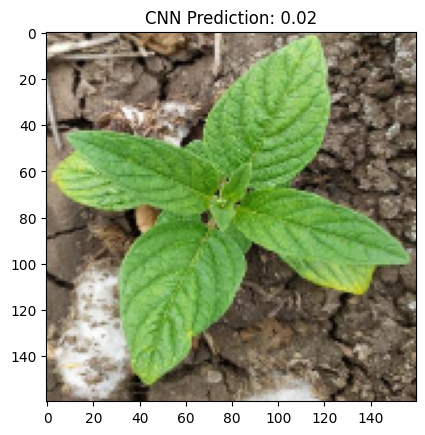

In [25]:
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms

# 1. Load the fine-tuned CNN model (WeedDetectionCNN)
class WeedDetectionCNN(nn.Module):
    def __init__(self):
        super(WeedDetectionCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 160, 160)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (16, 80, 80)
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Output: (32, 80, 80)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (32, 40, 40)
        )

        # Calculate the flattened size after convolutions
        self.flatten_size = 32 * 40 * 40

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 128),  # Adjusted size
            nn.ReLU(),
            nn.Linear(128, 1),  # Binary classification
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Load CNN model weights
cnn_model = WeedDetectionCNN()
cnn_model.load_state_dict(torch.load('/kaggle/working/dataset/trained_modelsave/cnn_weed_detection.pt'))
cnn_model.eval()

# 2. Load YOLO model using the `ultralytics` package
yolo_model = YOLO('/kaggle/working/dataset/trained_modelsave/best.pt')

# 3. Load and preprocess the image
image_path = '/kaggle/working/dataset/images/test/Copy of agri_0_3555.jpeg'  # Path to the image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 4. Run YOLO for object detection
results = yolo_model(image_rgb)  # YOLO model should be callable here

# 5. Visualize the results from YOLO
result = results[0]  # Access the first result in the list
result.show()  # Display the image with detections

# 6. Access YOLO bounding boxes if needed
boxes = result.boxes  # Access bounding boxes from the first result
print(f"Bounding Boxes (xywh): {boxes.xywh}")
print(f"Confidence Scores: {boxes.conf}")
print(f"Class IDs: {boxes.cls}")

# 7. Save the annotated image from YOLO
result.save("annotated_image.jpg")

# Save detection results as text file
result.save_txt("detection_results.txt")

# 8. Run CNN on detected crops if needed
for box in boxes.xywh:  # Loop through the bounding boxes detected by YOLO
    x_center, y_center, width, height = box
    x_center, y_center, width, height = int(x_center), int(y_center), int(width), int(height)

    # Crop the detected region (bounding box) from the image
    crop = image[y_center - height // 2: y_center + height // 2, x_center - width // 2: x_center + width // 2]

    # Resize for CNN
    crop_resized = cv2.resize(crop, (160, 160))  # Resize to match CNN input size
    crop_resized_rgb = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB)  # Convert to RGB

    # Convert crop to tensor
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    crop_tensor = transform(crop_resized_rgb).unsqueeze(0)  # Add batch dimension

    # Run CNN on the crop
    with torch.no_grad():
        cnn_output = cnn_model(crop_tensor)  # Get CNN prediction
        print(f"CNN Prediction for crop: {cnn_output.item()}")

# Optionally, display cropped image and its CNN prediction
    plt.imshow(crop_resized_rgb)
    plt.title(f"CNN Prediction: {cnn_output.item():.2f}")
    plt.show()



0: 640x640 4 weeds, 8.2ms
Speed: 3.0ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


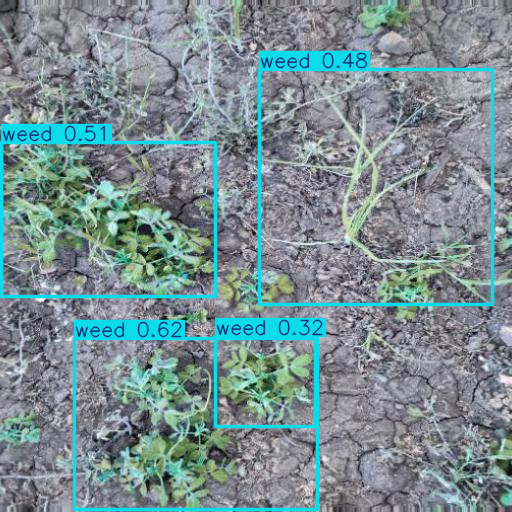

Bounding Boxes (xywh): tensor([[196.1400, 424.2988, 243.0250, 170.8338],
        [108.4345, 219.8714, 214.0145, 153.7544],
        [376.2548, 186.6510, 232.7205, 235.2767],
        [265.7612, 381.4093,  99.8955,  89.8647]], device='cuda:0')
Confidence Scores: tensor([0.6230, 0.5083, 0.4772, 0.3192], device='cuda:0')
Class IDs: tensor([1., 1., 1., 1.], device='cuda:0')
CNN Prediction for crop: 0.009596899151802063


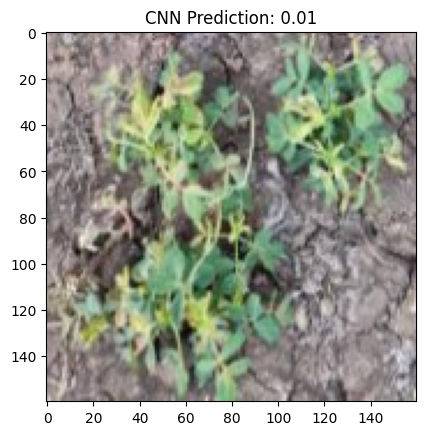

CNN Prediction for crop: 0.9176454544067383


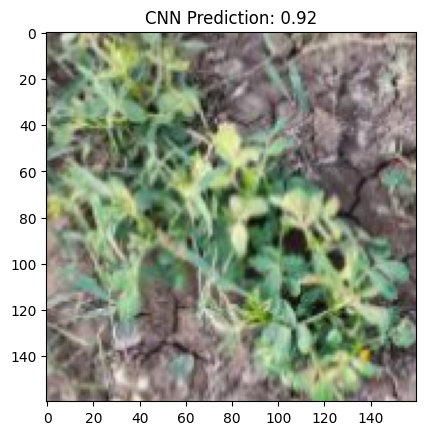

CNN Prediction for crop: 0.6416689157485962


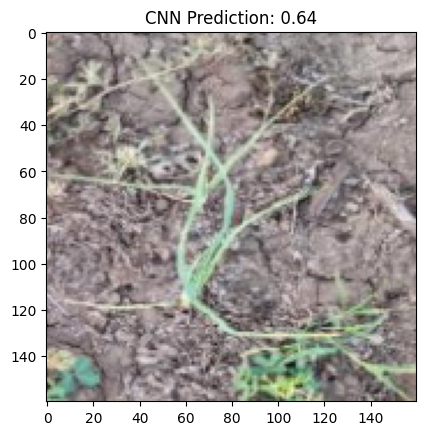

CNN Prediction for crop: 1.9886269910784904e-06


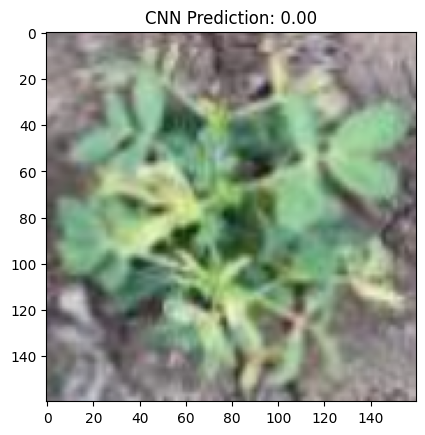

In [26]:
import torch
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms

# 1. Load the fine-tuned CNN model (WeedDetectionCNN)
class WeedDetectionCNN(nn.Module):
    def __init__(self):
        super(WeedDetectionCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 160, 160)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (16, 80, 80)
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # Output: (32, 80, 80)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: (32, 40, 40)
        )

        # Calculate the flattened size after convolutions
        self.flatten_size = 32 * 40 * 40

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 128),  # Adjusted size
            nn.ReLU(),
            nn.Linear(128, 1),  # Binary classification
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Load CNN model weights
cnn_model = WeedDetectionCNN()
cnn_model.load_state_dict(torch.load('/kaggle/working/dataset/trained_modelsave/cnn_weed_detection.pt'))
cnn_model.eval()  # Set CNN to evaluation mode

# 2. Load YOLO model using the `ultralytics` package
yolo_model = YOLO('/kaggle/working/dataset/trained_modelsave/best.pt')

# 3. Load and preprocess the image
image_path = '/kaggle/working/dataset/images/test/Copy of agri_0_2825.jpeg'  # Path to the image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 4. Run YOLO for object detection
results = yolo_model(image_rgb)  # YOLO model should be callable here

# 5. Visualize the results from YOLO
# results is a list, we need to access the first result (if there are multiple results)
result = results[0]  # Access the first result in the list
result.show()  # Display the image with detections

# 6. Access YOLO bounding boxes if needed
boxes = result.boxes  # Access bounding boxes from the first result
print(f"Bounding Boxes (xywh): {boxes.xywh}")
print(f"Confidence Scores: {boxes.conf}")
print(f"Class IDs: {boxes.cls}")

# 7. Save the annotated image from YOLO
result.save("annotated_image.jpg")

# Save detection results as text file
result.save_txt("detection_results.txt")

# 8. Run CNN on detected crops if needed
for box in boxes.xywh:  # Loop through the bounding boxes detected by YOLO
    x_center, y_center, width, height = box
    x_center, y_center, width, height = int(x_center), int(y_center), int(width), int(height)

    crop = image[y_center - height // 2: y_center + height // 2, x_center - width // 2: x_center + width // 2]

    # Resize for CNN
    crop_resized = cv2.resize(crop, (160, 160))  # Resize to match CNN input size
    crop_resized_rgb = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB)  # Convert to RGB

    # Convert crop to tensor
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    crop_tensor = transform(crop_resized_rgb).unsqueeze(0)  # Add batch dimension

    # Run CNN on the crop
    with torch.no_grad():
        cnn_output = cnn_model(crop_tensor)  # Get CNN prediction
        print(f"CNN Prediction for crop: {cnn_output.item()}")

# Optionally, display cropped image and its CNN prediction
    plt.imshow(crop_resized_rgb)
    plt.title(f"CNN Prediction: {cnn_output.item():.2f}")
    plt.show()


In [ ]:
# Thank You